In [3]:
import yfinance as yf
import pandas as pd

tickers = ["TSLA", "BND", "SPY"]
start_date = "2015-01-01"
end_date = "2026-06-30"

data = {}
for ticker in tickers:
    data[ticker] = yf.download(ticker, start=start_date, end=end_date, auto_adjust=False)

data["TSLA"].head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,,
2015-01-02,14.620667,14.620667,14.883333,14.217333,14.858000,71466000
2015-01-05,14.006000,14.006000,14.433333,13.810667,14.303333,80527500
2015-01-06,14.085333,14.085333,14.280000,13.614000,14.004000,93928500
2015-01-07,14.063333,14.063333,14.318667,13.985333,14.223333,44526000
2015-01-08,14.041333,14.041333,14.253333,14.000667,14.187333,51637500


In [2]:
print(data["TSLA"].columns)
print(data["TSLA"].shape)

MultiIndex([( 'Close', 'TSLA'),
            (  'High', 'TSLA'),
            (   'Low', 'TSLA'),
            (  'Open', 'TSLA'),
            ('Volume', 'TSLA')],
           names=['Price', 'Ticker'])
(2888, 5)


In [4]:
for ticker in tickers:
    data[ticker].columns = data[ticker].columns.droplevel(1)

data["TSLA"].head()

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2015-01-02,14.620667,14.620667,14.883333,14.217333,14.858000,71466000
2015-01-05,14.006000,14.006000,14.433333,13.810667,14.303333,80527500
2015-01-06,14.085333,14.085333,14.280000,13.614000,14.004000,93928500
2015-01-07,14.063333,14.063333,14.318667,13.985333,14.223333,44526000
2015-01-08,14.041333,14.041333,14.253333,14.000667,14.187333,51637500


In [5]:
for ticker in tickers:
    print(f"--- {ticker} ---")
    print(data[ticker].describe())
    print()

for ticker in tickers:
    print(f"--- {ticker} ---")
    print(data[ticker].dtypes)
    print()

for ticker in tickers:
    print(f"--- {ticker} ---")
    print(data[ticker].isnull().sum())
    print()

--- TSLA ---
Price    Adj Close        Close         High          Low         Open  \
count  2888.000000  2888.000000  2888.000000  2888.000000  2888.000000   
mean    148.773923   148.773923   151.990563   145.416731   148.797341   
std     138.895957   138.895957   141.852818   135.867193   138.977191   
min       9.578000     9.578000    10.331333     9.403333     9.488000   
25%      18.393499    18.393499    18.665168    18.023666    18.390833   
50%     133.437668   133.437668   136.053329   125.831669   131.496330   
75%     251.925831   251.925831   257.485008   245.832500   251.680004   
max     489.880005   489.880005   498.829987   485.329987   489.880005   

Price        Volume  
count  2.888000e+03  
mean   1.087922e+08  
std    7.082549e+07  
min    1.062000e+07  
25%    6.548325e+07  
50%    9.033615e+07  
75%    1.261204e+08  
max    9.140820e+08  

--- BND ---
Price    Adj Close        Close         High          Low         Open  \
count  2888.000000  2888.000000  28

In [6]:
for ticker in tickers:
    total_missing = data[ticker].isnull().sum().sum()
    print(f"{ticker}: {total_missing} total missing values")

TSLA: 0 total missing values
BND: 0 total missing values
SPY: 0 total missing values


In [7]:
for ticker in tickers:
    print(f"{ticker}: {data[ticker].dtypes.to_dict()}")

TSLA: {'Adj Close': dtype('float64'), 'Close': dtype('float64'), 'High': dtype('float64'), 'Low': dtype('float64'), 'Open': dtype('float64'), 'Volume': dtype('int64')}
BND: {'Adj Close': dtype('float64'), 'Close': dtype('float64'), 'High': dtype('float64'), 'Low': dtype('float64'), 'Open': dtype('float64'), 'Volume': dtype('int64')}
SPY: {'Adj Close': dtype('float64'), 'Close': dtype('float64'), 'High': dtype('float64'), 'Low': dtype('float64'), 'Open': dtype('float64'), 'Volume': dtype('int64')}


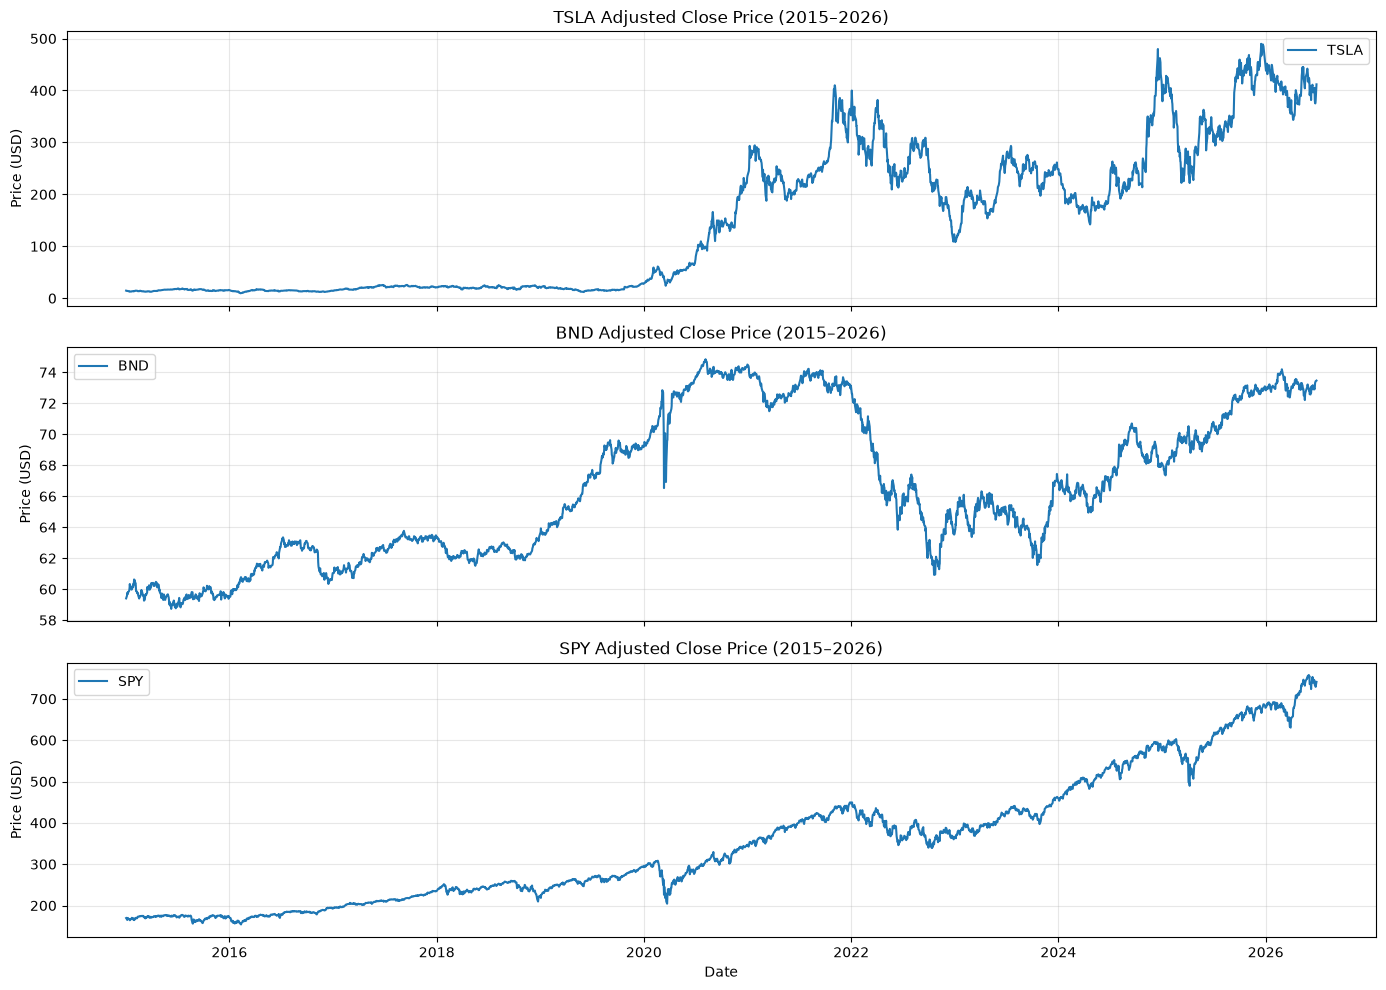

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, ticker in zip(axes, tickers):
    ax.plot(data[ticker].index, data[ticker]["Adj Close"], label=ticker)
    ax.set_title(f"{ticker} Adjusted Close Price (2015–2026)")
    ax.set_ylabel("Price (USD)")
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

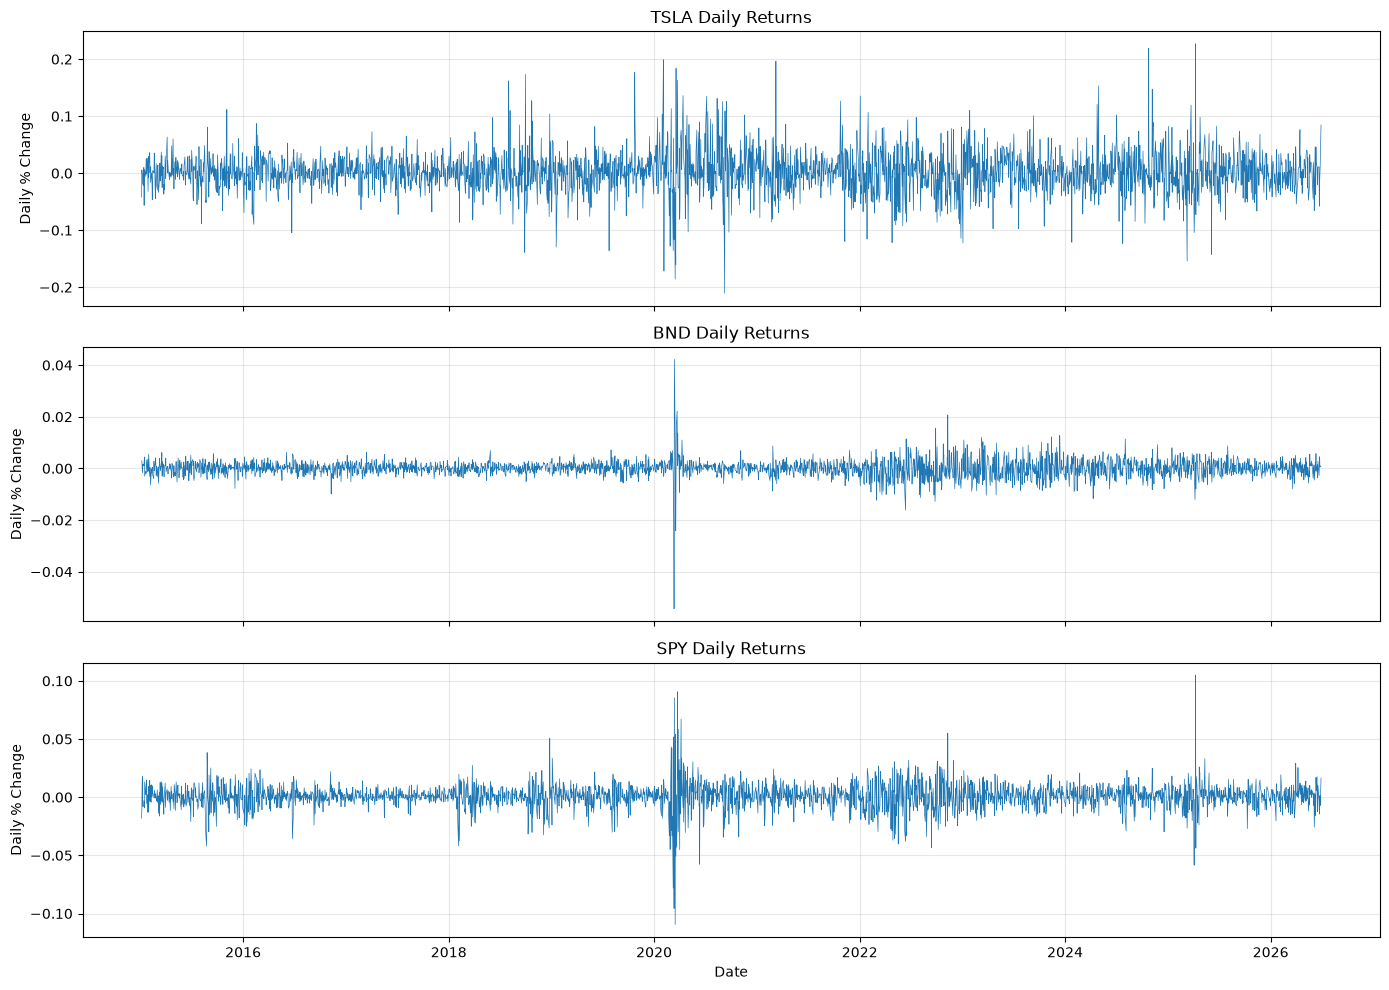

In [9]:
for ticker in tickers:
    data[ticker]["Daily Return"] = data[ticker]["Adj Close"].pct_change()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, ticker in zip(axes, tickers):
    ax.plot(data[ticker].index, data[ticker]["Daily Return"], linewidth=0.5)
    ax.set_title(f"{ticker} Daily Returns")
    ax.set_ylabel("Daily % Change")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

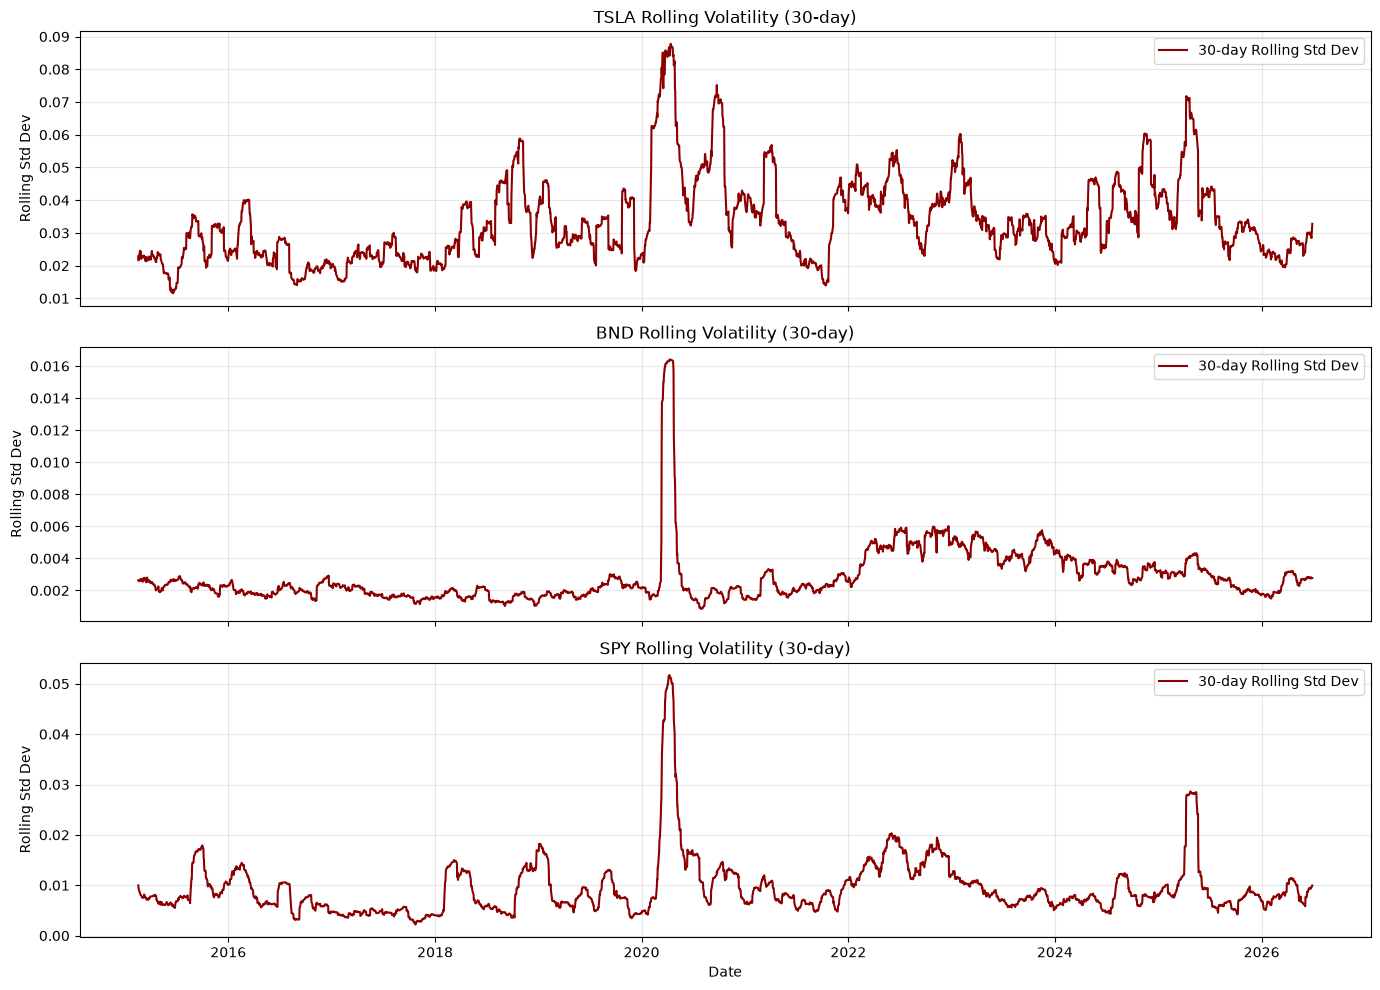

In [10]:
window = 30  # 30-day rolling window

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, ticker in zip(axes, tickers):
    rolling_mean = data[ticker]["Daily Return"].rolling(window=window).mean()
    rolling_std = data[ticker]["Daily Return"].rolling(window=window).std()

    ax.plot(data[ticker].index, rolling_std, label=f"{window}-day Rolling Std Dev", color="darkred")
    ax.set_title(f"{ticker} Rolling Volatility ({window}-day)")
    ax.set_ylabel("Rolling Std Dev")
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

In [11]:
for ticker in tickers:
    returns = data[ticker]["Daily Return"].dropna()
    mean = returns.mean()
    std = returns.std()

    # Flag days beyond 3 standard deviations from the mean
    outliers = data[ticker][(data[ticker]["Daily Return"] > mean + 3*std) | 
                              (data[ticker]["Daily Return"] < mean - 3*std)]

    print(f"--- {ticker}: {len(outliers)} outlier days (>3 std from mean) ---")
    print(outliers[["Daily Return"]].sort_values("Daily Return"))
    print()

--- TSLA: 46 outlier days (>3 std from mean) ---
Price       Daily Return
Date                    
2020-09-08     -0.210628
2020-03-16     -0.185778
2020-02-05     -0.171758
2020-03-18     -0.160344
2025-03-10     -0.154262
2025-06-05     -0.142599
2018-09-28     -0.139015
2019-07-25     -0.136137
2020-03-09     -0.135725
2019-01-18     -0.129711
2020-02-27     -0.128146
2024-07-24     -0.123346
2023-01-03     -0.122422
2022-04-26     -0.121841
2024-01-25     -0.121253
2021-11-09     -0.119903
2020-03-12     -0.116172
2022-01-27     -0.115542
2022-12-27     -0.114089
2018-08-07      0.109886
2023-01-27      0.110002
2015-11-04      0.111735
2020-08-17      0.112031
2020-03-02      0.113220
2025-03-24      0.119336
2024-04-24      0.120611
2020-08-31      0.125689
2020-09-14      0.125832
2021-10-25      0.126616
2018-10-23      0.127189
2020-08-12      0.131236
2020-07-06      0.134794
2022-01-03      0.135317
2020-04-13      0.136038
2020-02-04      0.137256
2024-11-06      0.147510
2

In [12]:
for ticker in tickers:
    returns = data[ticker]["Daily Return"].dropna()
    mean = returns.mean()
    std = returns.std()

    outliers = data[ticker][(data[ticker]["Daily Return"] > mean + 3*std) | 
                              (data[ticker]["Daily Return"] < mean - 3*std)]

    print(f"--- {ticker}: {len(outliers)} outlier days ---")
    print(f"Top 3 negative: {outliers['Daily Return'].nsmallest(3).to_dict()}")
    print(f"Top 3 positive: {outliers['Daily Return'].nlargest(3).to_dict()}")
    print()

--- TSLA: 46 outlier days ---
Top 3 negative: {Timestamp('2020-09-08 00:00:00'): -0.21062824320390794, Timestamp('2020-03-16 00:00:00'): -0.18577806455584012, Timestamp('2020-02-05 00:00:00'): -0.1717583947927872}
Top 3 positive: {Timestamp('2025-04-09 00:00:00'): 0.22689989839624536, Timestamp('2024-10-24 00:00:00'): 0.21919035070290427, Timestamp('2020-02-03 00:00:00'): 0.19894859376394902}

--- BND: 33 outlier days ---
Top 3 negative: {Timestamp('2020-03-12 00:00:00'): -0.05438530341591297, Timestamp('2020-03-18 00:00:00'): -0.024139619983421512, Timestamp('2020-03-17 00:00:00'): -0.02068585000703438}
Top 3 positive: {Timestamp('2020-03-13 00:00:00'): 0.04220113710983098, Timestamp('2020-03-23 00:00:00'): 0.02214907361099394, Timestamp('2022-11-10 00:00:00'): 0.02070246369063522}

--- SPY: 39 outlier days ---
Top 3 negative: {Timestamp('2020-03-16 00:00:00'): -0.10942376651191188, Timestamp('2020-03-12 00:00:00'): -0.09567704556786616, Timestamp('2020-03-09 00:00:00'): -0.0780945246

In [13]:
from statsmodels.tsa.stattools import adfuller

def run_adf_test(series, name):
    result = adfuller(series.dropna())
    print(f"--- ADF Test: {name} ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print(f"Critical Values: {result[4]}")
    if result[1] <= 0.05:
        print("=> Stationary (reject null hypothesis)")
    else:
        print("=> Non-stationary (fail to reject null hypothesis)")
    print()

for ticker in tickers:
    run_adf_test(data[ticker]["Adj Close"], f"{ticker} Closing Price")
    run_adf_test(data[ticker]["Daily Return"], f"{ticker} Daily Return")

--- ADF Test: TSLA Closing Price ---
ADF Statistic: -1.0696
p-value: 0.7270
Critical Values: {'1%': np.float64(-3.432638524105552), '5%': np.float64(-2.8625511137463935), '10%': np.float64(-2.567308245513228)}
=> Non-stationary (fail to reject null hypothesis)

--- ADF Test: TSLA Daily Return ---
ADF Statistic: -53.9719
p-value: 0.0000
Critical Values: {'1%': np.float64(-3.4326178883893763), '5%': np.float64(-2.862541999961805), '10%': np.float64(-2.567303393388591)}
=> Stationary (reject null hypothesis)

--- ADF Test: BND Closing Price ---
ADF Statistic: -1.0827
p-value: 0.7219
Critical Values: {'1%': np.float64(-3.432627366129768), '5%': np.float64(-2.862546185823105), '10%': np.float64(-2.567305621914905)}
=> Non-stationary (fail to reject null hypothesis)

--- ADF Test: BND Daily Return ---
ADF Statistic: -15.2161
p-value: 0.0000
Critical Values: {'1%': np.float64(-3.432627366129768), '5%': np.float64(-2.862546185823105), '10%': np.float64(-2.567305621914905)}
=> Stationary (rejec

## Stationarity Analysis (Augmented Dickey-Fuller Test)

For all three assets (TSLA, BND, SPY), the ADF test was run on both closing prices and daily returns:

- **Closing prices**: In every case, the p-value was well above 0.05 (e.g., TSLA: p=0.727, BND: p=0.722), so we fail to reject the null hypothesis of a unit root. This confirms closing prices are non-stationary — they trend over time and their statistical properties (mean, variance) change, which is expected for asset prices.

- **Daily returns**: In every case, the p-value was effectively 0.0000, well below 0.05, so we reject the null hypothesis. Daily returns are stationary — they fluctuate around a constant mean with roughly constant variance over time.

**Implication for modeling**: Since closing prices are non-stationary, an ARIMA model applied directly to price levels would violate its core assumptions. This confirms that differencing is required — i.e., the 'd' parameter in ARIMA(p,d,q) should be at least 1, since first-differencing prices is equivalent to modeling returns, which we've shown to already be stationary. This aligns with the Efficient Market Hypothesis: price levels carry a trend/random walk component, but the day-to-day changes behave more like white noise around a mean.

In [14]:
run_adf_test(data["SPY"]["Adj Close"], "SPY Closing Price")

--- ADF Test: SPY Closing Price ---
ADF Statistic: 1.3089
p-value: 0.9967
Critical Values: {'1%': np.float64(-3.4326241980933294), '5%': np.float64(-2.8625447866555227), '10%': np.float64(-2.567304877006608)}
=> Non-stationary (fail to reject null hypothesis)



In [15]:
confidence_level = 0.95

for ticker in tickers:
    returns = data[ticker]["Daily Return"].dropna()
    var_95 = returns.quantile(1 - confidence_level)
    print(f"{ticker}: 1-day VaR (95% confidence) = {var_95:.4f} ({var_95*100:.2f}%)")

TSLA: 1-day VaR (95% confidence) = -0.0517 (-5.17%)
BND: 1-day VaR (95% confidence) = -0.0048 (-0.48%)
SPY: 1-day VaR (95% confidence) = -0.0167 (-1.67%)


In [16]:
risk_free_rate_annual = 0.02  # approx 2% annual risk-free rate assumption
trading_days = 252

for ticker in tickers:
    returns = data[ticker]["Daily Return"].dropna()
    daily_rf = risk_free_rate_annual / trading_days
    excess_return = returns.mean() - daily_rf
    sharpe_ratio = (excess_return / returns.std()) * (trading_days ** 0.5)
    print(f"{ticker}: Annualized Sharpe Ratio = {sharpe_ratio:.4f}")

TSLA: Annualized Sharpe Ratio = 0.7595
BND: Annualized Sharpe Ratio = -0.0008
SPY: Annualized Sharpe Ratio = 0.7042


## Key Insights Summary

**Tesla (TSLA)**: Price grew from ~$9.58 to nearly $490 over the period — a ~50x increase — but with substantial volatility (daily VaR of -5.17%, the highest of the three assets). TSLA experienced sustained periods of elevated volatility rather than isolated spikes, consistent with its high-growth, high-risk profile. Despite this risk, its annualized Sharpe ratio (0.76) was comparable to SPY's, indicating the elevated risk was compensated by proportionally higher returns.

**Bonds (BND)**: Exhibited the lowest volatility and VaR (-0.48%) of the three assets, confirming its role as a portfolio stabilizer. However, its near-zero Sharpe ratio reflects weak risk-adjusted returns over this period, largely driven by a sustained price decline during the 2022 interest rate hiking cycle — a reminder that "low risk" does not guarantee positive returns, especially in rising-rate environments.

**S&P 500 (SPY)**: Delivered steady, moderate growth with volatility and VaR between TSLA and BND, as expected for a diversified index. Its Sharpe ratio (0.70) was nearly identical to TSLA's, suggesting that over this period, a diversified market-wide bet delivered similar risk-adjusted performance to a concentrated high-growth stock — without the extreme drawdown risk TSLA carries.

**Stationarity**: All three assets showed non-stationary closing prices (ADF p-values near 1.0) and stationary daily returns (ADF p-values ≈ 0.0000) — confirming that differencing (d=1 in ARIMA terms) is necessary before applying ARIMA-family models to price data, consistent with the Efficient Market Hypothesis's implication that price changes, not price levels, behave like a stationary process.

**Volatility clustering**: All three assets showed clear volatility clustering, with the most pronounced spikes occurring during the COVID-19 market crash (March 2020) and, more mutedly, during the 2022 rate-hiking cycle — reinforcing the need for models that account for time-varying volatility rather than assuming constant variance.

In [17]:
import os

os.makedirs("../data/processed", exist_ok=True)

for ticker in tickers:
    data[ticker].to_csv(f"../data/processed/{ticker}_processed.csv")
    print(f"Saved {ticker}_processed.csv")

Saved TSLA_processed.csv
Saved BND_processed.csv
Saved SPY_processed.csv


In [18]:
os.listdir("../data/processed")

['BND_processed.csv', 'SPY_processed.csv', 'TSLA_processed.csv']